In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo (Asegúrate de que coincidan con los de tu Notebook)
S = 1361           # Constante solar (W/m^2)
sigma = 5.67e-8    # Constante de Stefan-Boltzmann (W/m^2/K^4)
epsilon = 0.6      # Emisividad de la Tierra
alpha = 0.3        # Albedo constante (sin feedback)
C = 4e8            # Capacidad calorífica (ejemplo típico en J/m^2/K)

# 1. Ecuación diferencial de la temperatura (Sin feedback)
def dTdt(T):
    incoming = (1 - alpha) * S / 4
    outgoing = epsilon * sigma * T**4
    # La tasa de cambio es (Energía entrante - Energía saliente) / Capacidad calorífica
    return (incoming - outgoing) / C

# 2. Método de Runge-Kutta de 4to orden (RK4)
def rk4_step(T, dt):
    k1 = dTdt(T)
    k2 = dTdt(T + 0.5 * dt * k1)
    k3 = dTdt(T + 0.5 * dt * k2)
    k4 = dTdt(T + dt * k3)
    
    return T + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

In [2]:
# 3. Función del Albedo dependiente de la temperatura
def albedo(T):
    # Transición suave entre albedo alto (hielo, frío) y bajo (océano, cálido)
    # T_transition = 273 K, width = 10 K
    return 0.3 + 0.3 * (1 - np.tanh((T - 273) / 10)) / 2

# 4. Ecuación diferencial con feedback
def dTdt_feedback(T):
    a = albedo(T) # Calculamos el albedo dinámico
    incoming = (1 - a) * S / 4
    outgoing = epsilon * sigma * T**4
    
    return (incoming - outgoing) / C

# 5. Método RK4 adaptado para el modelo con feedback
def rk4_feedback(T, dt):
    k1 = dTdt_feedback(T)
    k2 = dTdt_feedback(T + 0.5 * dt * k1)
    k3 = dTdt_feedback(T + 0.5 * dt * k2)
    k4 = dTdt_feedback(T + dt * k3)
    
    return T + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

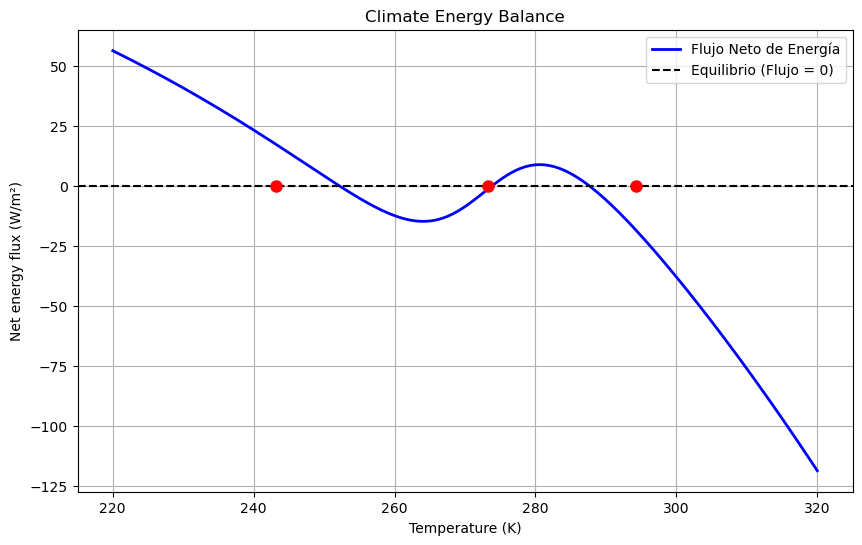

In [3]:
# Rango de temperaturas para analizar el equilibrio (de 220 K a 320 K)
T_range = np.linspace(220, 320, 200)
F = np.zeros(len(T_range))

# Calculamos el flujo neto de energía para cada temperatura
for i, T in enumerate(T_range):
    a = albedo(T)
    incoming = (1 - a) * S / 4
    outgoing = epsilon * sigma * T**4
    F[i] = incoming - outgoing  # Flujo neto (Energy in - Energy out)

# Graficar la curva de balance de energía
plt.figure(figsize=(10, 6))
plt.plot(T_range, F, 'b-', linewidth=2, label='Flujo Neto de Energía')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Equilibrio (Flujo = 0)')

# Puntos de equilibrio (Donde la curva cruza el 0)
plt.plot(243.2, 0, 'ro', markersize=8)
plt.plot(273.2, 0, 'ro', markersize=8)
plt.plot(294.3, 0, 'ro', markersize=8)

plt.xlabel("Temperature (K)")
plt.ylabel("Net energy flux (W/m²)")
plt.title("Climate Energy Balance")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of the Energy Balance Curve

| Temperature | Climate state |
|:--------------:|:---------------|
| **243.2 K** | Snowball Earth (Tierra totalmente congelada) |
| **273.2 K** | Unstable intermediate state (Estado intermedio inestable) |
| **294.3 K** | Warm climate similar to modern Earth (Clima cálido estable) |